In [1]:
!pip install earthengine-api geemap geopandas osmnx pandas shapely matplotlib openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 40.1 MB/s eta 0:00:00


In [2]:
from dataclasses import dataclass
from pathlib import Path
from typing import Optional
from io import StringIO

import ee
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point, Polygon, MultiPolygon
import matplotlib.pyplot as plt

print("Imports successful")

Imports successful


In [3]:
csv_text = """iit_name,short_name,city,state,latitude,longitude,fallback_radius_m,osm_query
Indian Institute of Technology Kharagpur,IIT Kharagpur,Kharagpur,West Bengal,22.3197,87.3095,2100,Indian Institute of Technology Kharagpur
Indian Institute of Technology Bombay,IIT Bombay,Mumbai,Maharashtra,19.1334,72.9133,1500,Indian Institute of Technology Bombay
Indian Institute of Technology Madras,IIT Madras,Chennai,Tamil Nadu,12.9915,80.2337,1600,Indian Institute of Technology Madras
Indian Institute of Technology Kanpur,IIT Kanpur,Kanpur,Uttar Pradesh,26.5123,80.2329,2100,Indian Institute of Technology Kanpur
Indian Institute of Technology Delhi,IIT Delhi,New Delhi,Delhi,28.5457,77.1928,900,Indian Institute of Technology Delhi
Indian Institute of Technology Guwahati,IIT Guwahati,Guwahati,Assam,26.1876,91.6919,1800,Indian Institute of Technology Guwahati
Indian Institute of Technology Roorkee,IIT Roorkee,Roorkee,Uttarakhand,29.8649,77.8965,1200,Indian Institute of Technology Roorkee
Indian Institute of Technology Ropar,IIT Ropar,Rupnagar,Punjab,30.9685,76.4731,1400,Indian Institute of Technology Ropar
Indian Institute of Technology Bhubaneswar,IIT Bhubaneswar,Bhubaneswar,Odisha,20.1499,85.6711,1800,Indian Institute of Technology Bhubaneswar
Indian Institute of Technology Gandhinagar,IIT Gandhinagar,Gandhinagar,Gujarat,23.2115,72.6842,1300,Indian Institute of Technology Gandhinagar
Indian Institute of Technology Hyderabad,IIT Hyderabad,Sangareddy,Telangana,17.5947,78.1235,1900,Indian Institute of Technology Hyderabad
Indian Institute of Technology Jodhpur,IIT Jodhpur,Jodhpur,Rajasthan,26.4750,73.1140,1900,Indian Institute of Technology Jodhpur
Indian Institute of Technology Patna,IIT Patna,Bihta,Bihar,25.5358,84.8514,1400,Indian Institute of Technology Patna
Indian Institute of Technology Indore,IIT Indore,Indore,Madhya Pradesh,22.5204,75.9204,1600,Indian Institute of Technology Indore
Indian Institute of Technology Mandi,IIT Mandi,Mandi,Himachal Pradesh,31.7754,76.9861,1500,Indian Institute of Technology Mandi
Indian Institute of Technology Varanasi BHU,IIT BHU,Varanasi,Uttar Pradesh,25.2623,82.9891,1100,Indian Institute of Technology BHU
Indian Institute of Technology Palakkad,IIT Palakkad,Palakkad,Kerala,10.8050,76.5669,1200,Indian Institute of Technology Palakkad
Indian Institute of Technology Tirupati,IIT Tirupati,Tirupati,Andhra Pradesh,13.6288,79.3945,1400,Indian Institute of Technology Tirupati
Indian Institute of Technology Dhanbad,IIT Dhanbad,Dhanbad,Jharkhand,23.8145,86.4412,1100,Indian Institute of Technology Dhanbad
Indian Institute of Technology Bhilai,IIT Bhilai,Bhilai,Chhattisgarh,21.2970,81.3220,1300,Indian Institute of Technology Bhilai
Indian Institute of Technology Goa,IIT Goa,Ponda,Goa,15.4220,73.9800,900,Indian Institute of Technology Goa
Indian Institute of Technology Jammu,IIT Jammu,Jammu,Jammu and Kashmir,32.8020,74.8970,1200,Indian Institute of Technology Jammu
Indian Institute of Technology Dharwad,IIT Dharwad,Dharwad,Karnataka,15.4896,74.9820,1400,Indian Institute of Technology Dharwad
"""

campuses = pd.read_csv(StringIO(csv_text))
campuses.head()

,iit_name,short_name,city,state,latitude,longitude,fallback_radius_m,osm_query
0,Indian Institute of Technology Kharagpur,IIT Kharagpur,Kharagpur,West Bengal,22.3197,87.3095,2100,Indian Institute of Technology Kharagpur
1,Indian Institute of Technology Bombay,IIT Bombay,Mumbai,Maharashtra,19.1334,72.9133,1500,Indian Institute of Technology Bombay
2,Indian Institute of Technology Madras,IIT Madras,Chennai,Tamil Nadu,12.9915,80.2337,1600,Indian Institute of Technology Madras
3,Indian Institute of Technology Kanpur,IIT Kanpur,Kanpur,Uttar Pradesh,26.5123,80.2329,2100,Indian Institute of Technology Kanpur
4,Indian Institute of Technology Delhi,IIT Delhi,New Delhi,Delhi,28.5457,77.1928,900,Indian Institute of Technology Delhi


In [4]:
OPEN_BUILDINGS_COLLECTION = "GOOGLE/Research/open-buildings-temporal/v1"
COUNT_BAND = "building_fractional_count"

@dataclass(frozen=True)
class CountConfig:
    year: int = 2023
    scale_m: int = 4
    max_pixels: int = 1_000_000_000
    campus_crs: str = "EPSG:4326"

def estimate_metric_crs(gdf):
    crs = gdf.estimate_utm_crs()
    return crs.to_string() if crs is not None else "EPSG:3857"

def initialize_earth_engine(project=None):
    if project:
        ee.Initialize(project=project)
    else:
        ee.Initialize()

def get_year_image(year):
    return (
        ee.ImageCollection(OPEN_BUILDINGS_COLLECTION)
        .filterDate(f"{year}-01-01", f"{year + 1}-01-01")
        .mosaic()
        .select(COUNT_BAND)
    )

def shapely_to_ee_geometry(geometry):
    return ee.Geometry(geometry.__geo_interface__)

def fallback_buffer(row, config):
    point_gdf = gpd.GeoDataFrame(
        geometry=[Point(float(row["longitude"]), float(row["latitude"]))],
        crs=config.campus_crs,
    )
    metric_crs = estimate_metric_crs(point_gdf)
    metric = point_gdf.to_crs(metric_crs)
    buffered = metric.buffer(float(row["fallback_radius_m"]))
    return gpd.GeoSeries(buffered, crs=metric_crs).to_crs(config.campus_crs).iloc[0]

def fetch_osm_boundary(row):
    try:
        import osmnx as ox
        gdf = ox.geocode_to_gdf(str(row["osm_query"]))
        if gdf.empty:
            return None
        geom = gdf.geometry.iloc[0]
        if geom.geom_type in {"Polygon", "MultiPolygon"}:
            return geom
        return None
    except Exception:
        return None

def build_campus_aoi(row, config, prefer_osm=True):
    osm_geom = fetch_osm_boundary(row) if prefer_osm else None
    if osm_geom is not None:
        return {
            "iit_name": row["iit_name"],
            "short_name": row["short_name"],
            "source": "osm_boundary",
            "geometry": osm_geom,
        }
    return {
        "iit_name": row["iit_name"],
        "short_name": row["short_name"],
        "source": "fallback_buffer",
        "geometry": fallback_buffer(row, config),
    }

def estimate_building_count(image, geometry, config):
    ee_geom = shapely_to_ee_geometry(geometry)
    result = image.reduceRegion(
        reducer=ee.Reducer.sum(),
        geometry=ee_geom,
        scale=config.scale_m,
        maxPixels=config.max_pixels,
        bestEffort=True,
    ).getInfo()
    value = result.get(COUNT_BAND)
    return float(value) if value is not None else float("nan")

def aoi_area_sq_km(geometry, config):
    gdf = gpd.GeoDataFrame(geometry=[geometry], crs=config.campus_crs)
    metric_crs = estimate_metric_crs(gdf)
    return float(gdf.to_crs(metric_crs).area.iloc[0] / 1_000_000)

def run_counts(campuses, year=2023, prefer_osm=True, config=None):
    cfg = config or CountConfig(year=year)
    image = get_year_image(year)
    rows = []
    geoms = []

    for _, campus in campuses.iterrows():
        print("Processing:", campus["short_name"])
        aoi = build_campus_aoi(campus, cfg, prefer_osm=prefer_osm)
        count = estimate_building_count(image, aoi["geometry"], cfg)
        area = aoi_area_sq_km(aoi["geometry"], cfg)

        rows.append({
            "iit_name": aoi["iit_name"],
            "short_name": aoi["short_name"],
            "year": year,
            "aoi_source": aoi["source"],
            "aoi_area_sq_km": area,
            "estimated_building_count": count,
            "buildings_per_sq_km": count / area if area else float("nan"),
        })
        geoms.append(aoi["geometry"])

    aoi_gdf = gpd.GeoDataFrame(pd.DataFrame(rows), geometry=geoms, crs=cfg.campus_crs)
    aoi_gdf = aoi_gdf.sort_values("estimated_building_count", ascending=False)
    result = pd.DataFrame(aoi_gdf.drop(columns="geometry"))
    return result, aoi_gdf

print("Functions ready")

Functions ready


In [5]:
ee.Authenticate()

In [6]:
initialize_earth_engine(project="titanium-bus-501107-q4")
print("Earth Engine initialized")

Earth Engine initialized


In [7]:
YEAR = 2023
PREFER_OSM_BOUNDARIES = False

config = CountConfig(year=YEAR)

results, campus_aois = run_counts(
    campuses,
    year=YEAR,
    prefer_osm=PREFER_OSM_BOUNDARIES,
    config=config,
)

results

Processing: IIT Kharagpur
Processing: IIT Bombay
Processing: IIT Madras
Processing: IIT Kanpur
Processing: IIT Delhi
Processing: IIT Guwahati
Processing: IIT Roorkee
Processing: IIT Ropar
Processing: IIT Bhubaneswar
Processing: IIT Gandhinagar
Processing: IIT Hyderabad
Processing: IIT Jodhpur
Processing: IIT Patna
Processing: IIT Indore
Processing: IIT Mandi
Processing: IIT BHU
Processing: IIT Palakkad
Processing: IIT Tirupati
Processing: IIT Dhanbad
Processing: IIT Bhilai
Processing: IIT Goa
Processing: IIT Jammu
Processing: IIT Dharwad


,iit_name,short_name,year,aoi_source,aoi_area_sq_km,estimated_building_count,buildings_per_sq_km
3,Indian Institute of Technology Kanpur,IIT Kanpur,2023,fallback_buffer,13.832179,498.410424,36.032676
0,Indian Institute of Technology Kharagpur,IIT Kharagpur,2023,fallback_buffer,13.832179,356.710918,25.788484
2,Indian Institute of Technology Madras,IIT Madras,2023,fallback_buffer,8.029564,266.637869,33.207016
6,Indian Institute of Technology Roorkee,IIT Roorkee,2023,fallback_buffer,4.516630,209.202344,46.318240
18,Indian Institute of Technology Dhanbad,IIT Dhanbad,2023,fallback_buffer,3.795224,188.918892,49.778065
5,Indian Institute of Technology Guwahati,IIT Guwahati,2023,fallback_buffer,10.162417,165.822465,16.317227
1,Indian Institute of Technology Bombay,IIT Bombay,2023,fallback_buffer,7.057234,151.199725,21.424785
15,Indian Institute of Technology Varanasi BHU,IIT BHU,2023,fallback_buffer,3.795224,104.003850,27.403879
12,Indian Institute of Technology Patna,IIT Patna,2023,fallback_buffer,6.147635,73.990810,12.035654
4,Indian Institute of Technology Delhi,IIT Delhi,2023,fallback_buffer,2.540604,70.840740,27.883422


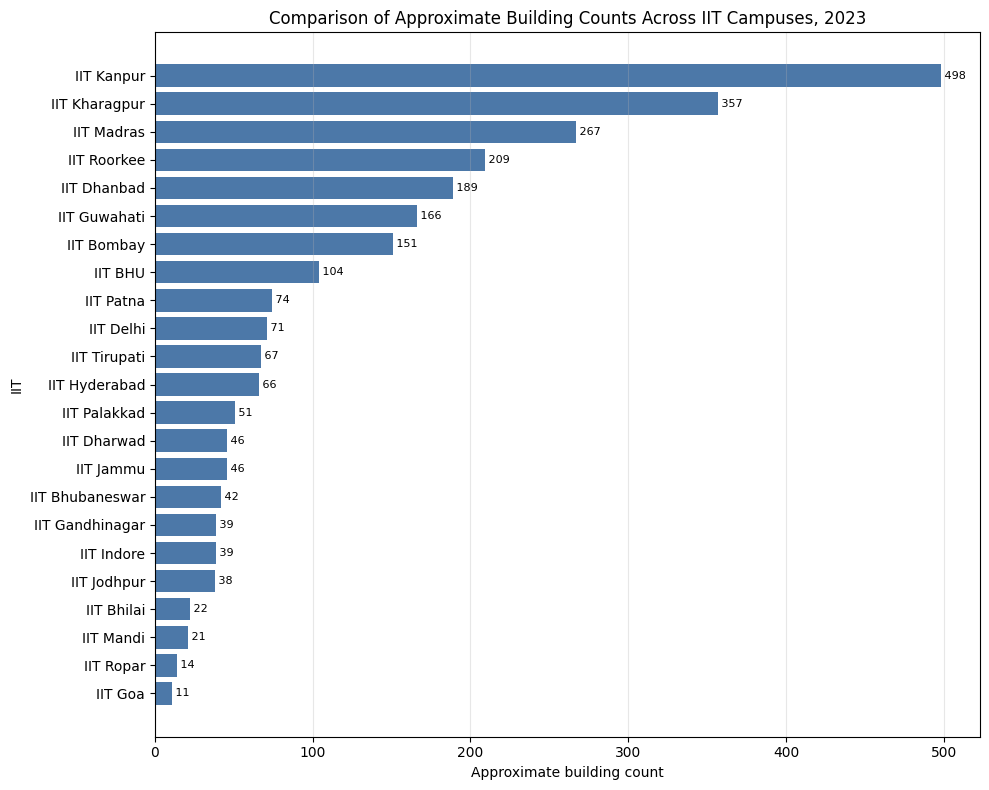

In [8]:
import matplotlib.pyplot as plt

plot_df = results.copy()

plot_df["estimated_building_count_rounded"] = (
    plot_df["estimated_building_count"].round().astype(int)
)

plot_df = plot_df.sort_values("estimated_building_count_rounded", ascending=True)

plt.figure(figsize=(10, 8))

plt.barh(
    plot_df["short_name"],
    plot_df["estimated_building_count_rounded"],
    color="#4C78A8"
)

plt.xlabel("Approximate building count")
plt.ylabel("IIT")
plt.title("Comparison of Approximate Building Counts Across IIT Campuses, 2023")
plt.grid(axis="x", alpha=0.3)

for index, value in enumerate(plot_df["estimated_building_count_rounded"]):
    plt.text(value, index, f" {value}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("iit_building_count_comparison_2023.png", dpi=300)
plt.show()

In [20]:
!pip install beautifulsoup4 requests -q

In [21]:
import re
import time
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import quote

HEADERS = {
    "User-Agent": "IITCampusAreaScraper/1.0 academic research"
}

wiki_titles = {
    "IIT Kharagpur": "IIT Kharagpur",
    "IIT Bombay": "IIT Bombay",
    "IIT Madras": "IIT Madras",
    "IIT Kanpur": "IIT Kanpur",
    "IIT Delhi": "IIT Delhi",
    "IIT Guwahati": "IIT Guwahati",
    "IIT Roorkee": "IIT Roorkee",
    "IIT Ropar": "Indian Institute of Technology Ropar",
    "IIT Bhubaneswar": "Indian Institute of Technology Bhubaneswar",
    "IIT Gandhinagar": "Indian Institute of Technology Gandhinagar",
    "IIT Hyderabad": "Indian Institute of Technology Hyderabad",
    "IIT Jodhpur": "Indian Institute of Technology Jodhpur",
    "IIT Patna": "Indian Institute of Technology Patna",
    "IIT Indore": "Indian Institute of Technology Indore",
    "IIT Mandi": "Indian Institute of Technology Mandi",
    "IIT BHU": "IIT (BHU) Varanasi",
    "IIT Palakkad": "Indian Institute of Technology Palakkad",
    "IIT Tirupati": "Indian Institute of Technology Tirupati",
    "IIT Dhanbad": "IIT (ISM) Dhanbad",
    "IIT Bhilai": "Indian Institute of Technology Bhilai",
    "IIT Goa": "Indian Institute of Technology Goa",
    "IIT Jammu": "Indian Institute of Technology Jammu",
    "IIT Dharwad": "Indian Institute of Technology Dharwad",
}

def extract_area_acres(text):
    text = text.replace(",", "")

    acre_match = re.search(r"(\d+(?:\.\d+)?)\s*(?:acres|acre)", text, re.IGNORECASE)
    if acre_match:
        return float(acre_match.group(1)), "acres"

    ha_match = re.search(r"(\d+(?:\.\d+)?)\s*(?:ha|hectares|hectare)", text, re.IGNORECASE)
    if ha_match:
        return float(ha_match.group(1)) * 2.47105, "hectares_converted_to_acres"

    return None, None

def scrape_wikipedia_campus_area(title):
    url = "https://en.wikipedia.org/wiki/" + quote(title.replace(" ", "_"))
    r = requests.get(url, headers=HEADERS, timeout=30)
    r.raise_for_status()

    soup = BeautifulSoup(r.text, "html.parser")
    page_text = soup.get_text(" ", strip=True)

    # First try infobox rows containing Campus
    infobox = soup.find("table", class_="infobox")
    if infobox:
        for row in infobox.find_all("tr"):
            row_text = row.get_text(" ", strip=True)
            if "Campus" in row_text:
                acres, source_unit = extract_area_acres(row_text)
                if acres:
                    return acres, source_unit, row_text, url

    # Fallback: search full page text
    acres, source_unit = extract_area_acres(page_text)
    if acres:
        return acres, source_unit, "matched_from_page_text", url

    return None, None, "not_found", url

area_rows = []

for _, row in campuses.iterrows():
    short = row["short_name"]
    title = wiki_titles.get(short, row["iit_name"])

    print("Scraping:", short, "->", title)

    try:
        area_acres, source_unit, matched_text, url = scrape_wikipedia_campus_area(title)
    except Exception as e:
        area_acres, source_unit, matched_text, url = None, None, f"failed: {e}", None

    area_rows.append({
        "short_name": short,
        "iit_name": row["iit_name"],
        "wikipedia_title": title,
        "reported_area_acres": area_acres,
        "area_source_unit": source_unit,
        "matched_text": matched_text,
        "source_url": url,
    })

    time.sleep(1.5)

area_df = pd.DataFrame(area_rows)
area_df

Scraping: IIT Kharagpur -> IIT Kharagpur
Scraping: IIT Bombay -> IIT Bombay
Scraping: IIT Madras -> IIT Madras
Scraping: IIT Kanpur -> IIT Kanpur
Scraping: IIT Delhi -> IIT Delhi
Scraping: IIT Guwahati -> IIT Guwahati
Scraping: IIT Roorkee -> IIT Roorkee
Scraping: IIT Ropar -> Indian Institute of Technology Ropar
Scraping: IIT Bhubaneswar -> Indian Institute of Technology Bhubaneswar
Scraping: IIT Gandhinagar -> Indian Institute of Technology Gandhinagar
Scraping: IIT Hyderabad -> Indian Institute of Technology Hyderabad
Scraping: IIT Jodhpur -> Indian Institute of Technology Jodhpur
Scraping: IIT Patna -> Indian Institute of Technology Patna
Scraping: IIT Indore -> Indian Institute of Technology Indore
Scraping: IIT Mandi -> Indian Institute of Technology Mandi
Scraping: IIT BHU -> IIT (BHU) Varanasi
Scraping: IIT Palakkad -> Indian Institute of Technology Palakkad
Scraping: IIT Tirupati -> Indian Institute of Technology Tirupati
Scraping: IIT Dhanbad -> IIT (ISM) Dhanbad
Scraping: II

,short_name,iit_name,wikipedia_title,reported_area_acres,area_source_unit,matched_text,source_url
0,IIT Kharagpur,Indian Institute of Technology Kharagpur,IIT Kharagpur,2200.00,acres,"Campus 2,200 acres (890 ha) Suburban",https://en.wikipedia.org/wiki/IIT_Kharagpur
1,IIT Bombay,Indian Institute of Technology Bombay,IIT Bombay,545.00,acres,Campus 545 acres (221 ha) Urban,https://en.wikipedia.org/wiki/IIT_Bombay
2,IIT Madras,Indian Institute of Technology Madras,IIT Madras,620.00,acres,Campus Urban 620 acres (2.5 km 2 ),https://en.wikipedia.org/wiki/IIT_Madras
3,IIT Kanpur,Indian Institute of Technology Kanpur,IIT Kanpur,1055.00,acres,"Campus Urban, 1,055 acres (427 ha)",https://en.wikipedia.org/wiki/IIT_Kanpur
4,IIT Delhi,Indian Institute of Technology Delhi,IIT Delhi,375.00,acres,Campus 375 acres (1.52 km 2 ) Urban,https://en.wikipedia.org/wiki/IIT_Delhi
5,IIT Guwahati,Indian Institute of Technology Guwahati,IIT Guwahati,703.95,acres,"Campus Urban , 703.95 acres (2.8488 km 2 )",https://en.wikipedia.org/wiki/IIT_Guwahati
6,IIT Roorkee,Indian Institute of Technology Roorkee,IIT Roorkee,365.00,acres,Campus Urban 365 acres (1.48 km 2 ),https://en.wikipedia.org/wiki/IIT_Roorkee
7,IIT Ropar,Indian Institute of Technology Ropar,Indian Institute of Technology Ropar,525.00,acres,Campus Urban 525 acres (2.12 km 2 ),https://en.wikipedia.org/wiki/Indian_Institute...
8,IIT Bhubaneswar,Indian Institute of Technology Bhubaneswar,Indian Institute of Technology Bhubaneswar,936.00,acres,Campus Rural 936 acres (3.79 km 2 ),https://en.wikipedia.org/wiki/Indian_Institute...
9,IIT Gandhinagar,Indian Institute of Technology Gandhinagar,Indian Institute of Technology Gandhinagar,399.00,acres,Campus 399 acres (1.61 km 2 ) Urban,https://en.wikipedia.org/wiki/Indian_Institute...


In [22]:
area_df.to_csv("iit_reported_campus_area_wikipedia.csv", index=False)
area_df

,short_name,iit_name,wikipedia_title,reported_area_acres,area_source_unit,matched_text,source_url
0,IIT Kharagpur,Indian Institute of Technology Kharagpur,IIT Kharagpur,2200.00,acres,"Campus 2,200 acres (890 ha) Suburban",https://en.wikipedia.org/wiki/IIT_Kharagpur
1,IIT Bombay,Indian Institute of Technology Bombay,IIT Bombay,545.00,acres,Campus 545 acres (221 ha) Urban,https://en.wikipedia.org/wiki/IIT_Bombay
2,IIT Madras,Indian Institute of Technology Madras,IIT Madras,620.00,acres,Campus Urban 620 acres (2.5 km 2 ),https://en.wikipedia.org/wiki/IIT_Madras
3,IIT Kanpur,Indian Institute of Technology Kanpur,IIT Kanpur,1055.00,acres,"Campus Urban, 1,055 acres (427 ha)",https://en.wikipedia.org/wiki/IIT_Kanpur
4,IIT Delhi,Indian Institute of Technology Delhi,IIT Delhi,375.00,acres,Campus 375 acres (1.52 km 2 ) Urban,https://en.wikipedia.org/wiki/IIT_Delhi
5,IIT Guwahati,Indian Institute of Technology Guwahati,IIT Guwahati,703.95,acres,"Campus Urban , 703.95 acres (2.8488 km 2 )",https://en.wikipedia.org/wiki/IIT_Guwahati
6,IIT Roorkee,Indian Institute of Technology Roorkee,IIT Roorkee,365.00,acres,Campus Urban 365 acres (1.48 km 2 ),https://en.wikipedia.org/wiki/IIT_Roorkee
7,IIT Ropar,Indian Institute of Technology Ropar,Indian Institute of Technology Ropar,525.00,acres,Campus Urban 525 acres (2.12 km 2 ),https://en.wikipedia.org/wiki/Indian_Institute...
8,IIT Bhubaneswar,Indian Institute of Technology Bhubaneswar,Indian Institute of Technology Bhubaneswar,936.00,acres,Campus Rural 936 acres (3.79 km 2 ),https://en.wikipedia.org/wiki/Indian_Institute...
9,IIT Gandhinagar,Indian Institute of Technology Gandhinagar,Indian Institute of Technology Gandhinagar,399.00,acres,Campus 399 acres (1.61 km 2 ) Urban,https://en.wikipedia.org/wiki/Indian_Institute...


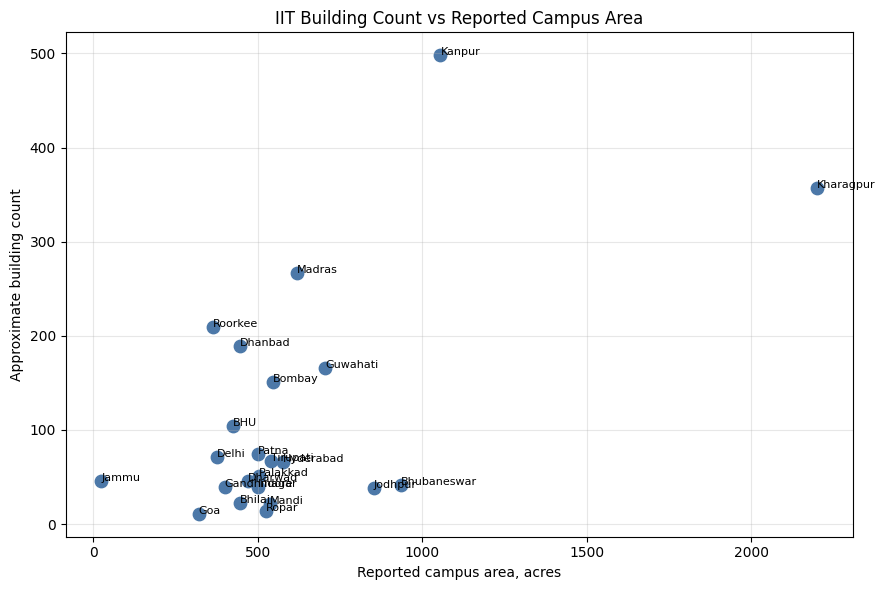

In [23]:
import matplotlib.pyplot as plt

scatter_df = results.merge(
    area_df[["short_name", "reported_area_acres"]],
    on="short_name",
    how="left"
)

scatter_df["building_count_rounded"] = (
    scatter_df["estimated_building_count"].round().astype(int)
)

scatter_df = scatter_df.dropna(subset=["reported_area_acres", "building_count_rounded"])

plt.figure(figsize=(9, 6))

plt.scatter(
    scatter_df["reported_area_acres"],
    scatter_df["building_count_rounded"],
    color="#4C78A8",
    s=80
)

for _, row in scatter_df.iterrows():
    plt.text(
        row["reported_area_acres"],
        row["building_count_rounded"],
        row["short_name"].replace("IIT ", ""),
        fontsize=8
    )

plt.xlabel("Reported campus area, acres")
plt.ylabel("Approximate building count")
plt.title("IIT Building Count vs Reported Campus Area")
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("iit_buildings_vs_reported_area_scatter.png", dpi=300)
plt.show()

In [9]:
!pip install geopandas pyproj matplotlib requests -q

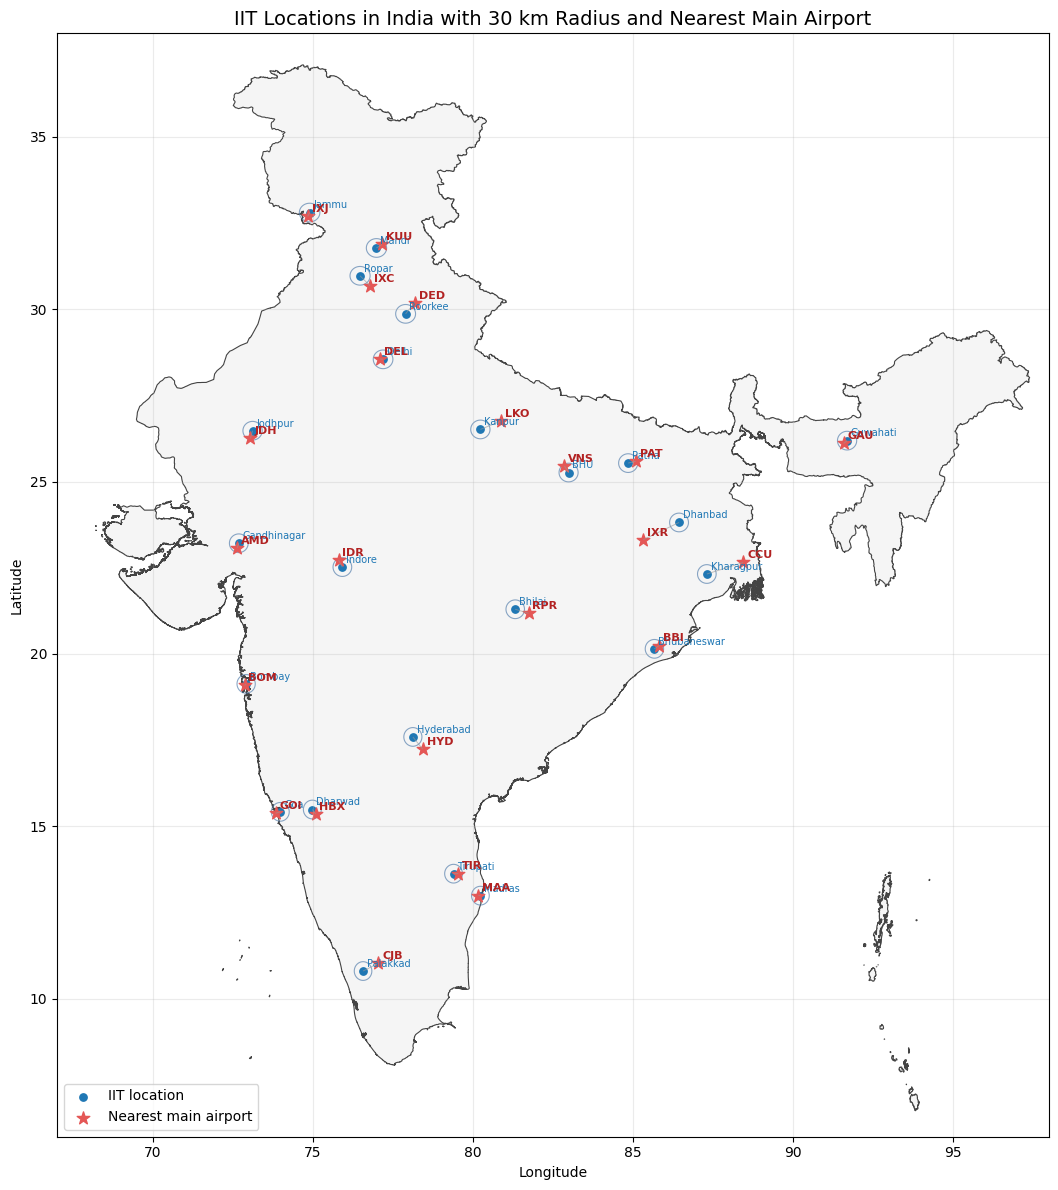

,short_name,nearest_airport,nearest_airport_iata,airport_city,distance_to_airport_km
15,IIT BHU,Lal Bahadur Shastri International Airport,VNS,Varanasi,24.782603
19,IIT Bhilai,Swami Vivekananda Airport,RPR,Raipur,45.150600
8,IIT Bhubaneswar,Biju Patnaik International Airport,BBI,Bhubaneswar,18.561660
1,IIT Bombay,Chhatrapati Shivaji Maharaj International Airport,BOM,Mumbai,6.978381
4,IIT Delhi,Indira Gandhi International Airport,DEL,New Delhi,9.155391
18,IIT Dhanbad,Birsa Munda Airport,IXR,Ranchi,127.008844
22,IIT Dharwad,Hubballi Airport,HBX,Hubballi,17.952152
9,IIT Gandhinagar,Sardar Vallabhbhai Patel International Airport,AMD,Ahmedabad,15.713408
20,IIT Goa,Dabolim Airport,GOI,Goa,16.590459
5,IIT Guwahati,Lokpriya Gopinath Bordoloi International Airport,GAU,Guwahati,13.923871


In [10]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Point, Polygon, LineString
from pyproj import Geod
from io import StringIO

airport_csv = """airport_name,iata,city,latitude,longitude
Indira Gandhi International Airport,DEL,New Delhi,28.5562,77.1000
Netaji Subhas Chandra Bose International Airport,CCU,Kolkata,22.6547,88.4467
Chhatrapati Shivaji Maharaj International Airport,BOM,Mumbai,19.0896,72.8656
Chennai International Airport,MAA,Chennai,12.9941,80.1709
Chaudhary Charan Singh International Airport,LKO,Lucknow,26.7606,80.8893
Lokpriya Gopinath Bordoloi International Airport,GAU,Guwahati,26.1061,91.5859
Dehradun Jolly Grant Airport,DED,Dehradun,30.1897,78.1803
Shaheed Bhagat Singh International Airport,IXC,Chandigarh,30.6735,76.7885
Biju Patnaik International Airport,BBI,Bhubaneswar,20.2444,85.8178
Sardar Vallabhbhai Patel International Airport,AMD,Ahmedabad,23.0772,72.6347
Rajiv Gandhi International Airport,HYD,Hyderabad,17.2403,78.4294
Jodhpur Airport,JDH,Jodhpur,26.2511,73.0489
Jay Prakash Narayan Airport,PAT,Patna,25.5913,85.0879
Devi Ahilya Bai Holkar Airport,IDR,Indore,22.7218,75.8011
Kullu Manali Airport,KUU,Bhuntar,31.8767,77.1544
Lal Bahadur Shastri International Airport,VNS,Varanasi,25.4524,82.8593
Coimbatore International Airport,CJB,Coimbatore,11.0300,77.0434
Cochin International Airport,COK,Kochi,10.1520,76.4019
Tirupati Airport,TIR,Tirupati,13.6325,79.5433
Birsa Munda Airport,IXR,Ranchi,23.3143,85.3217
Swami Vivekananda Airport,RPR,Raipur,21.1804,81.7388
Dabolim Airport,GOI,Goa,15.3808,73.8314
Manohar International Airport,GOX,Mopa,15.7300,73.8600
Jammu Airport,IXJ,Jammu,32.6891,74.8374
Hubballi Airport,HBX,Hubballi,15.3617,75.0849
"""

airports = pd.read_csv(StringIO(airport_csv))
geod = Geod(ellps="WGS84")

def geodesic_circle(lon, lat, radius_km=30):
    angles = list(range(0, 360, 3))
    lons, lats, _ = geod.fwd(
        [lon] * len(angles),
        [lat] * len(angles),
        angles,
        [radius_km * 1000] * len(angles)
    )
    return Polygon(zip(lons, lats))

def distance_km(lon1, lat1, lon2, lat2):
    _, _, dist_m = geod.inv(lon1, lat1, lon2, lat2)
    return dist_m / 1000

nearest_rows = []

for _, iit in campuses.iterrows():
    distances = airports.apply(
        lambda a: distance_km(
            iit["longitude"], iit["latitude"],
            a["longitude"], a["latitude"]
        ),
        axis=1
    )

    nearest_idx = distances.idxmin()
    nearest_airport = airports.loc[nearest_idx]

    nearest_rows.append({
        "iit_name": iit["iit_name"],
        "short_name": iit["short_name"],
        "iit_latitude": iit["latitude"],
        "iit_longitude": iit["longitude"],
        "nearest_airport": nearest_airport["airport_name"],
        "nearest_airport_iata": nearest_airport["iata"],
        "airport_city": nearest_airport["city"],
        "airport_latitude": nearest_airport["latitude"],
        "airport_longitude": nearest_airport["longitude"],
        "distance_to_airport_km": distances.loc[nearest_idx],
    })

nearest_airports = pd.DataFrame(nearest_rows)

iit_gdf = gpd.GeoDataFrame(
    nearest_airports,
    geometry=[
        Point(lon, lat)
        for lon, lat in zip(nearest_airports["iit_longitude"], nearest_airports["iit_latitude"])
    ],
    crs="EPSG:4326"
)

airport_gdf = gpd.GeoDataFrame(
    nearest_airports,
    geometry=[
        Point(lon, lat)
        for lon, lat in zip(nearest_airports["airport_longitude"], nearest_airports["airport_latitude"])
    ],
    crs="EPSG:4326"
)

circle_gdf = gpd.GeoDataFrame(
    nearest_airports[["short_name"]].copy(),
    geometry=[
        geodesic_circle(lon, lat, radius_km=30)
        for lon, lat in zip(nearest_airports["iit_longitude"], nearest_airports["iit_latitude"])
    ],
    crs="EPSG:4326"
)

line_gdf = gpd.GeoDataFrame(
    nearest_airports[["short_name", "nearest_airport_iata"]].copy(),
    geometry=[
        LineString([
            (row["iit_longitude"], row["iit_latitude"]),
            (row["airport_longitude"], row["airport_latitude"])
        ])
        for _, row in nearest_airports.iterrows()
    ],
    crs="EPSG:4326"
)

india_url = "https://raw.githubusercontent.com/datameet/maps/master/Country/india-osm.geojson"
india = gpd.read_file(india_url)

fig, ax = plt.subplots(figsize=(11, 12))

india.plot(ax=ax, color="#F5F5F5", edgecolor="#444444", linewidth=0.8)

circle_gdf.plot(
    ax=ax,
    facecolor="none",
    edgecolor="#4C78A8",
    linewidth=0.8,
    alpha=0.65
)

line_gdf.plot(
    ax=ax,
    color="#999999",
    linewidth=0.7,
    alpha=0.6
)

iit_gdf.plot(
    ax=ax,
    color="#1F77B4",
    markersize=28,
    label="IIT location"
)

airport_gdf.drop_duplicates("nearest_airport_iata").plot(
    ax=ax,
    color="#E45756",
    marker="*",
    markersize=90,
    label="Nearest main airport"
)

for _, row in nearest_airports.iterrows():
    ax.text(
        row["iit_longitude"] + 0.12,
        row["iit_latitude"] + 0.12,
        row["short_name"].replace("IIT ", ""),
        fontsize=7,
        color="#1F77B4"
    )

for _, row in nearest_airports.drop_duplicates("nearest_airport_iata").iterrows():
    ax.text(
        row["airport_longitude"] + 0.12,
        row["airport_latitude"] + 0.12,
        row["nearest_airport_iata"],
        fontsize=8,
        fontweight="bold",
        color="#B22222"
    )

ax.set_title("IIT Locations in India with 30 km Radius and Nearest Main Airport", fontsize=14)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_xlim(67, 98)
ax.set_ylim(6, 38)
ax.grid(alpha=0.25)
ax.legend(loc="lower left")

plt.tight_layout()
plt.savefig("iit_locations_30km_nearest_airports_updated.png", dpi=300)
plt.show()

nearest_airports.to_csv("iit_nearest_airports_updated.csv", index=False)

nearest_airports[
    [
        "short_name",
        "nearest_airport",
        "nearest_airport_iata",
        "airport_city",
        "distance_to_airport_km"
    ]
].sort_values("short_name")

In [11]:
!pip install requests -q

In [12]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from urllib.parse import quote

In [13]:
OPENALEX_API_KEY = ""

USER_AGENT = "IITResearchMetrics/1.0 academic noncommercial research"
HEADERS = {"User-Agent": USER_AGENT}

In [14]:
wiki_titles = {
    "IIT Kharagpur": "IIT Kharagpur",
    "IIT Bombay": "IIT Bombay",
    "IIT Madras": "IIT Madras",
    "IIT Kanpur": "IIT Kanpur",
    "IIT Delhi": "IIT Delhi",
    "IIT Guwahati": "IIT Guwahati",
    "IIT Roorkee": "IIT Roorkee",
    "IIT Ropar": "Indian Institute of Technology Ropar",
    "IIT Bhubaneswar": "Indian Institute of Technology Bhubaneswar",
    "IIT Gandhinagar": "Indian Institute of Technology Gandhinagar",
    "IIT Hyderabad": "Indian Institute of Technology Hyderabad",
    "IIT Jodhpur": "Indian Institute of Technology Jodhpur",
    "IIT Patna": "Indian Institute of Technology Patna",
    "IIT Indore": "Indian Institute of Technology Indore",
    "IIT Mandi": "Indian Institute of Technology Mandi",
    "IIT BHU": "IIT (BHU) Varanasi",
    "IIT Palakkad": "Indian Institute of Technology Palakkad",
    "IIT Tirupati": "Indian Institute of Technology Tirupati",
    "IIT Dhanbad": "IIT (ISM) Dhanbad",
    "IIT Bhilai": "Indian Institute of Technology Bhilai",
    "IIT Goa": "Indian Institute of Technology Goa",
    "IIT Jammu": "Indian Institute of Technology Jammu",
    "IIT Dharwad": "Indian Institute of Technology Dharwad",
}

In [15]:
def get_openalex_metrics(iit_name):
    url = "https://api.openalex.org/institutions"
    params = {
        "search": iit_name,
        "filter": "country_code:IN",
        "select": "id,display_name,works_count,cited_by_count,summary_stats",
        "per-page": 1
    }

    if OPENALEX_API_KEY:
        params["api_key"] = OPENALEX_API_KEY

    r = requests.get(url, params=params, headers=HEADERS, timeout=30)
    r.raise_for_status()

    data = r.json()
    results = data.get("results", [])

    if not results:
        return {
            "openalex_id": None,
            "openalex_display_name": None,
            "works_count": None,
            "cited_by_count": None,
            "h_index": None,
            "i10_index": None,
        }

    inst = results[0]
    summary = inst.get("summary_stats") or {}

    return {
        "openalex_id": inst.get("id"),
        "openalex_display_name": inst.get("display_name"),
        "works_count": inst.get("works_count"),
        "cited_by_count": inst.get("cited_by_count"),
        "h_index": summary.get("h_index"),
        "i10_index": summary.get("i10_index"),
    }


openalex_rows = []

for _, row in campuses.iterrows():
    print("OpenAlex:", row["short_name"])
    metrics = get_openalex_metrics(row["iit_name"])
    metrics["short_name"] = row["short_name"]
    metrics["iit_name"] = row["iit_name"]
    openalex_rows.append(metrics)
    time.sleep(0.5)

openalex_df = pd.DataFrame(openalex_rows)
openalex_df

OpenAlex: IIT Kharagpur
OpenAlex: IIT Bombay
OpenAlex: IIT Madras
OpenAlex: IIT Kanpur
OpenAlex: IIT Delhi
OpenAlex: IIT Guwahati
OpenAlex: IIT Roorkee
OpenAlex: IIT Ropar
OpenAlex: IIT Bhubaneswar
OpenAlex: IIT Gandhinagar
OpenAlex: IIT Hyderabad
OpenAlex: IIT Jodhpur
OpenAlex: IIT Patna
OpenAlex: IIT Indore
OpenAlex: IIT Mandi
OpenAlex: IIT BHU
OpenAlex: IIT Palakkad
OpenAlex: IIT Tirupati
OpenAlex: IIT Dhanbad
OpenAlex: IIT Bhilai
OpenAlex: IIT Goa
OpenAlex: IIT Jammu
OpenAlex: IIT Dharwad


,openalex_id,openalex_display_name,works_count,cited_by_count,h_index,i10_index,short_name,iit_name
0,https://openalex.org/I145894827,Indian Institute of Technology Kharagpur,71565,3474730,397,71003,IIT Kharagpur,Indian Institute of Technology Kharagpur
1,https://openalex.org/I162827531,Indian Institute of Technology Bombay,65489,3072228,404,59954,IIT Bombay,Indian Institute of Technology Bombay
2,https://openalex.org/I24676775,Indian Institute of Technology Madras,67408,2620624,363,55781,IIT Madras,Indian Institute of Technology Madras
3,https://openalex.org/I94234084,Indian Institute of Technology Kanpur,52240,2361486,323,45547,IIT Kanpur,Indian Institute of Technology Kanpur
4,https://openalex.org/I68891433,Indian Institute of Technology Delhi,72068,3030138,392,61286,IIT Delhi,Indian Institute of Technology Delhi
5,https://openalex.org/I1317621060,Indian Institute of Technology Guwahati,34317,1512666,282,32656,IIT Guwahati,Indian Institute of Technology Guwahati
6,https://openalex.org/I154851008,Indian Institute of Technology Roorkee,51669,2302683,377,45043,IIT Roorkee,Indian Institute of Technology Roorkee
7,https://openalex.org/I119241673,Indian Institute of Technology Ropar,8623,248690,135,6184,IIT Ropar,Indian Institute of Technology Ropar
8,https://openalex.org/I99729588,Indian Institute of Technology Bhubaneswar,10146,278300,172,6305,IIT Bhubaneswar,Indian Institute of Technology Bhubaneswar
9,https://openalex.org/I27674431,Indian Institute of Technology Gandhinagar,9467,342583,188,5314,IIT Gandhinagar,Indian Institute of Technology Gandhinagar


In [17]:
import random
import time
from urllib.parse import quote
import requests
import pandas as pd

USER_AGENT = "IITResearchMetrics/1.0 (academic noncommercial research; contact: your-email@example.com)"
HEADERS = {"User-Agent": USER_AGENT}

def safe_get(url, params=None, headers=None, timeout=30, max_retries=5):
    for attempt in range(max_retries):
        r = requests.get(url, params=params, headers=headers, timeout=timeout)

        if r.status_code == 429:
            wait_time = 10 + attempt * 10
            print(f"Rate limited. Waiting {wait_time} seconds...")
            time.sleep(wait_time)
            continue

        if r.status_code >= 500:
            wait_time = 5 + attempt * 5
            print(f"Server issue. Waiting {wait_time} seconds...")
            time.sleep(wait_time)
            continue

        return r

    return r


def resolve_wikipedia_title(title):
    url = "https://en.wikipedia.org/w/api.php"
    params = {
        "action": "query",
        "format": "json",
        "titles": title,
        "redirects": 1
    }

    r = safe_get(url, params=params, headers=HEADERS, timeout=30)

    if r.status_code == 404:
        return title

    r.raise_for_status()

    pages = r.json()["query"]["pages"]
    page = list(pages.values())[0]

    if "missing" in page:
        return title

    return page.get("title", title)


def get_pageviews(title, start="2025010100", end="2025123100"):
    resolved_title = resolve_wikipedia_title(title)
    encoded_title = quote(resolved_title.replace(" ", "_"), safe="")

    url = (
        "https://wikimedia.org/api/rest_v1/metrics/pageviews/per-article/"
        f"en.wikipedia.org/all-access/user/{encoded_title}/daily/{start}/{end}"
    )

    r = safe_get(url, headers=HEADERS, timeout=30)

    if r.status_code == 404:
        return {
            "wikipedia_title": resolved_title,
            "wikipedia_pageviews_2025": None,
            "wiki_status": "page_not_found"
        }

    r.raise_for_status()

    items = r.json().get("items", [])
    total_views = sum(item.get("views", 0) for item in items)

    return {
        "wikipedia_title": resolved_title,
        "wikipedia_pageviews_2025": total_views,
        "wiki_status": "ok"
    }


wiki_rows = []

for _, row in campuses.iterrows():
    short = row["short_name"]
    title = wiki_titles.get(short, row["iit_name"])

    print("Wikipedia:", short, "->", title)

    try:
        pageview_data = get_pageviews(title)
    except Exception as e:
        print("Failed:", short, e)
        pageview_data = {
            "wikipedia_title": title,
            "wikipedia_pageviews_2025": None,
            "wiki_status": "failed"
        }

    pageview_data["short_name"] = short
    pageview_data["iit_name"] = row["iit_name"]

    wiki_rows.append(pageview_data)

    time.sleep(3 + random.random() * 2)

wiki_df = pd.DataFrame(wiki_rows)
wiki_df

Wikipedia: IIT Kharagpur -> IIT Kharagpur
Wikipedia: IIT Bombay -> IIT Bombay
Wikipedia: IIT Madras -> IIT Madras
Wikipedia: IIT Kanpur -> IIT Kanpur
Wikipedia: IIT Delhi -> IIT Delhi
Wikipedia: IIT Guwahati -> IIT Guwahati
Wikipedia: IIT Roorkee -> IIT Roorkee
Wikipedia: IIT Ropar -> Indian Institute of Technology Ropar
Wikipedia: IIT Bhubaneswar -> Indian Institute of Technology Bhubaneswar
Wikipedia: IIT Gandhinagar -> Indian Institute of Technology Gandhinagar
Wikipedia: IIT Hyderabad -> Indian Institute of Technology Hyderabad
Wikipedia: IIT Jodhpur -> Indian Institute of Technology Jodhpur
Wikipedia: IIT Patna -> Indian Institute of Technology Patna
Wikipedia: IIT Indore -> Indian Institute of Technology Indore
Wikipedia: IIT Mandi -> Indian Institute of Technology Mandi
Wikipedia: IIT BHU -> IIT (BHU) Varanasi
Wikipedia: IIT Palakkad -> Indian Institute of Technology Palakkad
Wikipedia: IIT Tirupati -> Indian Institute of Technology Tirupati
Wikipedia: IIT Dhanbad -> IIT (ISM) D

,wikipedia_title,wikipedia_pageviews_2025,wiki_status,short_name,iit_name
0,IIT Kharagpur,184194,ok,IIT Kharagpur,Indian Institute of Technology Kharagpur
1,IIT Bombay,168835,ok,IIT Bombay,Indian Institute of Technology Bombay
2,IIT Madras,162902,ok,IIT Madras,Indian Institute of Technology Madras
3,IIT Kanpur,79655,ok,IIT Kanpur,Indian Institute of Technology Kanpur
4,IIT Delhi,100493,ok,IIT Delhi,Indian Institute of Technology Delhi
5,IIT Guwahati,45274,ok,IIT Guwahati,Indian Institute of Technology Guwahati
6,IIT Roorkee,117137,ok,IIT Roorkee,Indian Institute of Technology Roorkee
7,IIT Ropar,29803,ok,IIT Ropar,Indian Institute of Technology Ropar
8,IIT Bhubaneswar,23570,ok,IIT Bhubaneswar,Indian Institute of Technology Bhubaneswar
9,IIT Gandhinagar,19996,ok,IIT Gandhinagar,Indian Institute of Technology Gandhinagar


In [18]:
metrics_df = openalex_df.merge(
    wiki_df,
    on=["short_name", "iit_name"],
    how="left"
)

metrics_df.to_csv("iit_openalex_wikipedia_metrics_updated.csv", index=False)
metrics_df

,openalex_id,openalex_display_name,works_count,cited_by_count,h_index,i10_index,short_name,iit_name,wikipedia_title,wikipedia_pageviews_2025,wiki_status
0,https://openalex.org/I145894827,Indian Institute of Technology Kharagpur,71565,3474730,397,71003,IIT Kharagpur,Indian Institute of Technology Kharagpur,IIT Kharagpur,184194,ok
1,https://openalex.org/I162827531,Indian Institute of Technology Bombay,65489,3072228,404,59954,IIT Bombay,Indian Institute of Technology Bombay,IIT Bombay,168835,ok
2,https://openalex.org/I24676775,Indian Institute of Technology Madras,67408,2620624,363,55781,IIT Madras,Indian Institute of Technology Madras,IIT Madras,162902,ok
3,https://openalex.org/I94234084,Indian Institute of Technology Kanpur,52240,2361486,323,45547,IIT Kanpur,Indian Institute of Technology Kanpur,IIT Kanpur,79655,ok
4,https://openalex.org/I68891433,Indian Institute of Technology Delhi,72068,3030138,392,61286,IIT Delhi,Indian Institute of Technology Delhi,IIT Delhi,100493,ok
5,https://openalex.org/I1317621060,Indian Institute of Technology Guwahati,34317,1512666,282,32656,IIT Guwahati,Indian Institute of Technology Guwahati,IIT Guwahati,45274,ok
6,https://openalex.org/I154851008,Indian Institute of Technology Roorkee,51669,2302683,377,45043,IIT Roorkee,Indian Institute of Technology Roorkee,IIT Roorkee,117137,ok
7,https://openalex.org/I119241673,Indian Institute of Technology Ropar,8623,248690,135,6184,IIT Ropar,Indian Institute of Technology Ropar,IIT Ropar,29803,ok
8,https://openalex.org/I99729588,Indian Institute of Technology Bhubaneswar,10146,278300,172,6305,IIT Bhubaneswar,Indian Institute of Technology Bhubaneswar,IIT Bhubaneswar,23570,ok
9,https://openalex.org/I27674431,Indian Institute of Technology Gandhinagar,9467,342583,188,5314,IIT Gandhinagar,Indian Institute of Technology Gandhinagar,IIT Gandhinagar,19996,ok


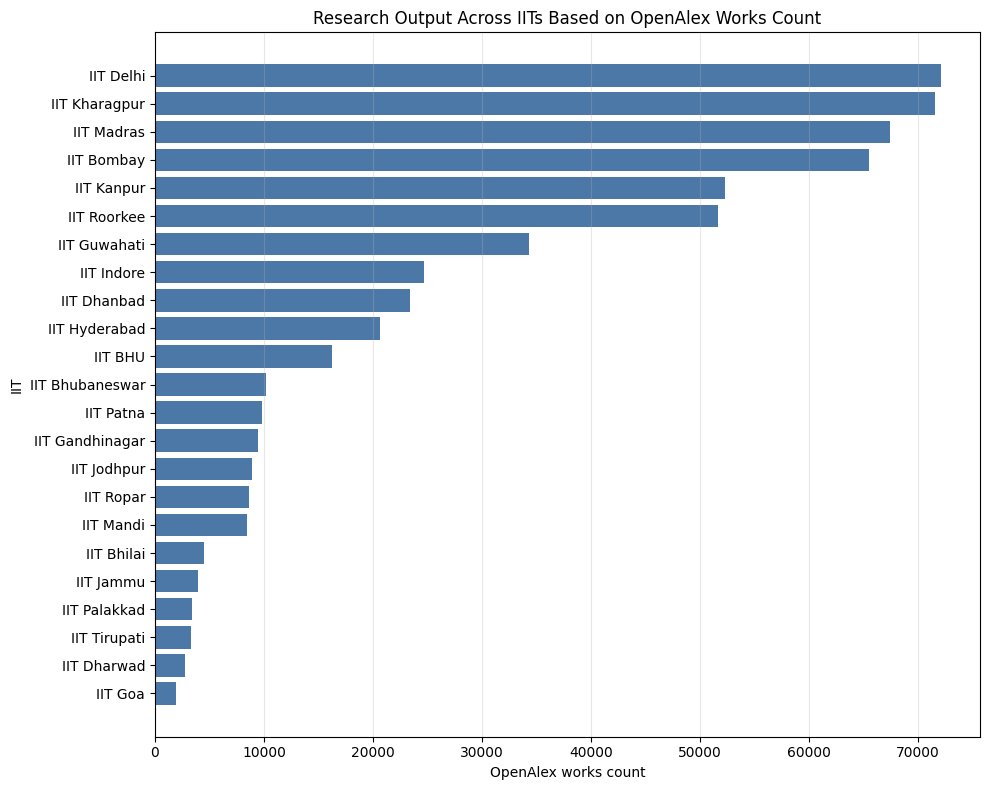

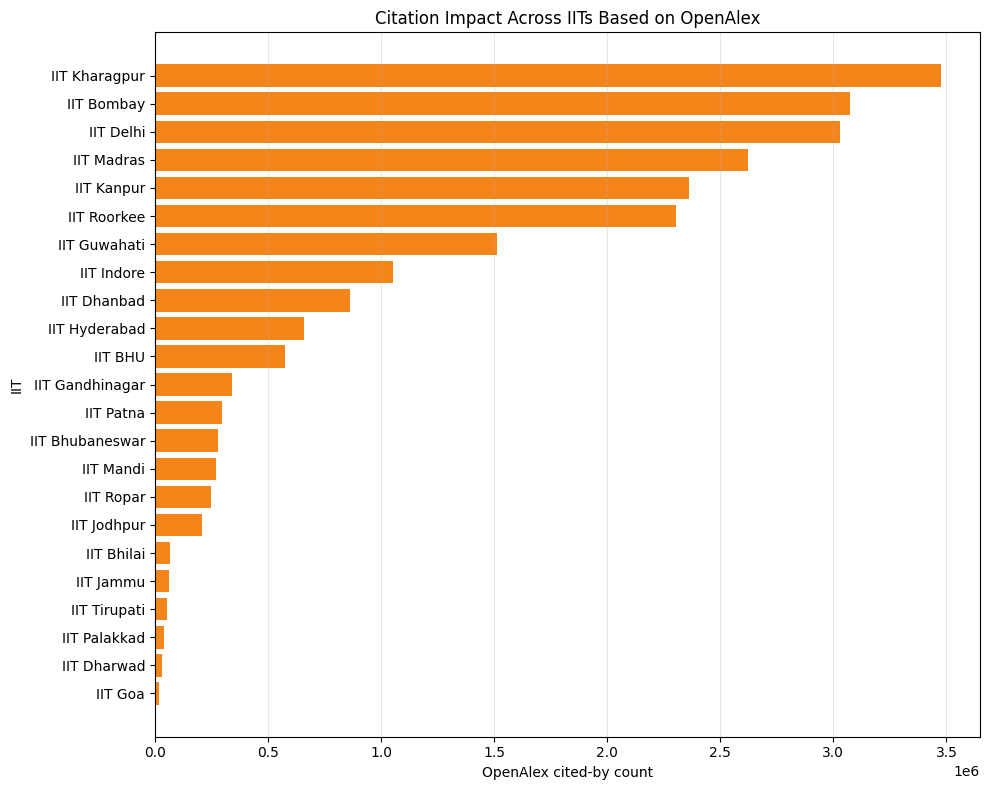

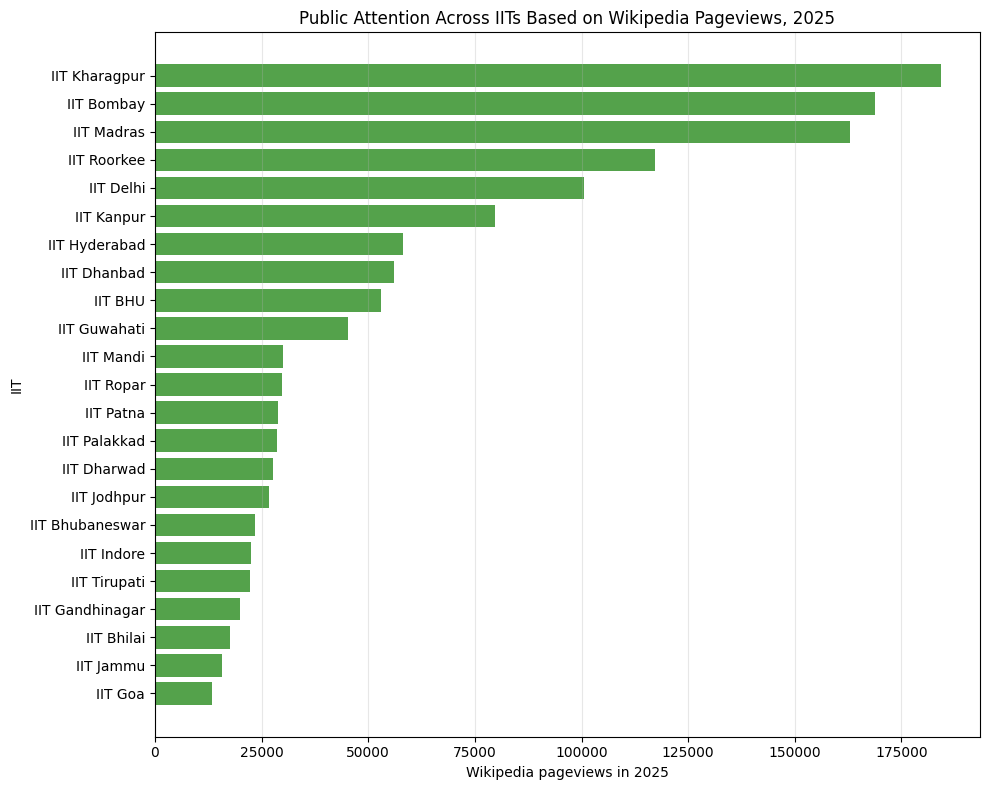

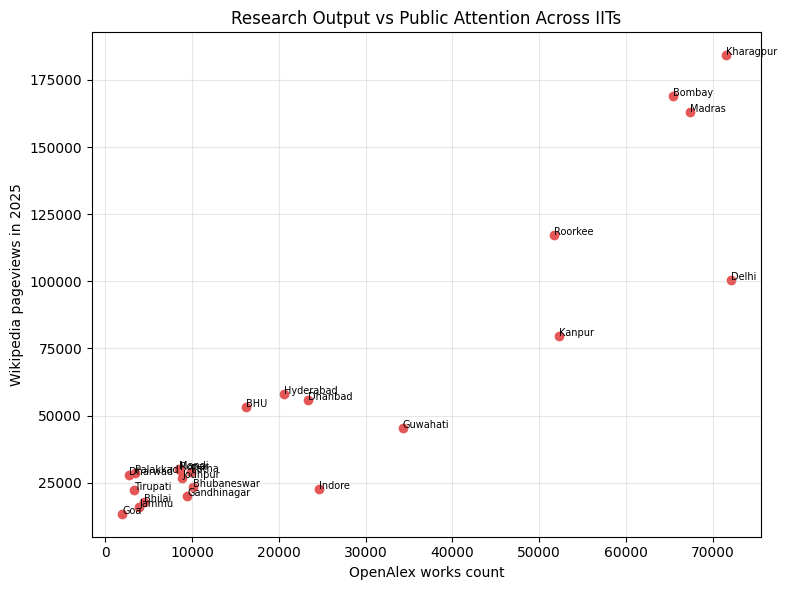

In [19]:
plot_df = metrics_df.copy()

df1 = plot_df.sort_values("works_count", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df1["short_name"], df1["works_count"], color="#4C78A8")
plt.xlabel("OpenAlex works count")
plt.ylabel("IIT")
plt.title("Research Output Across IITs Based on OpenAlex Works Count")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("iit_openalex_works_count_updated.png", dpi=300)
plt.show()

df2 = plot_df.sort_values("cited_by_count", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df2["short_name"], df2["cited_by_count"], color="#F58518")
plt.xlabel("OpenAlex cited-by count")
plt.ylabel("IIT")
plt.title("Citation Impact Across IITs Based on OpenAlex")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("iit_openalex_citations_updated.png", dpi=300)
plt.show()

df3 = plot_df.dropna(subset=["wikipedia_pageviews_2025"])
df3 = df3.sort_values("wikipedia_pageviews_2025", ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(df3["short_name"], df3["wikipedia_pageviews_2025"], color="#54A24B")
plt.xlabel("Wikipedia pageviews in 2025")
plt.ylabel("IIT")
plt.title("Public Attention Across IITs Based on Wikipedia Pageviews, 2025")
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.savefig("iit_wikipedia_pageviews_2025_updated.png", dpi=300)
plt.show()

scatter_df = plot_df.dropna(subset=["works_count", "wikipedia_pageviews_2025"])

plt.figure(figsize=(8, 6))
plt.scatter(
    scatter_df["works_count"],
    scatter_df["wikipedia_pageviews_2025"],
    color="#E45756"
)

for _, row in scatter_df.iterrows():
    plt.text(
        row["works_count"],
        row["wikipedia_pageviews_2025"],
        row["short_name"].replace("IIT ", ""),
        fontsize=7
    )

plt.xlabel("OpenAlex works count")
plt.ylabel("Wikipedia pageviews in 2025")
plt.title("Research Output vs Public Attention Across IITs")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("iit_research_vs_wikipedia_attention_updated.png", dpi=300)
plt.show()